Figure s17: Lymphocyte count, eczema, IBD, and dermatitis colocalization for IL18R1 and IL19RAP eQTL and pcQTL.  A QTL nominal p-values for each gene’s expression and each PC vs genomic position. If the phenotype has any significant credible sets, a plot is shown for each credible set, with credible set variants highlighted and colors given by variant LD with the credible-set lead variant. B GWAS variant nominal p-values vs QTL nominal p-values for each gene’s expression and each PC, with credible set variants highlighted and the highest PPH4 (probability of colocalization) between any QTL phenotype credible set and any GWAS credible set. C Colocalizations between credible sets in the cluster, colocalized is PPH4>0.75.

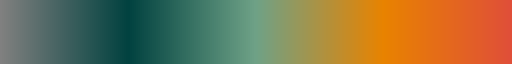

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *

%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

genotype_palette = {0: '#FDCC98', 1: '#E98324', 2: '#A44D24'}

ld_palette = LinearSegmentedColormap.from_list(
    "darkblue_green_yellow_red",
    ["grey", "#014240", "#6FA287", "#E98300", "#E04F39"]
)
ld_norm = mpl.colors.Normalize(vmin=0, vmax=1)
ld_palette

In [374]:
example_tissue_id= 'Skin_Sun_Exposed_Lower_leg'

example_cluster_id = 'ENSG00000115604.10_ENSG00000115607.9'
example_signal_id = 'ENSG00000115604.10_ENSG00000115607.9_pc2_cs_1-gwas_Astle_et_al_2016_Lymphocyte_counts_cluster_ENSG00000115604.10_ENSG00000115607.9_cs_1-gwas_EAGLE_Eczema_cluster_ENSG00000115604.10_ENSG00000115607.9_cs_1-gwas_IBD.EUR.Inflammatory_Bowel_Disease_cluster_ENSG00000115604.10_ENSG00000115607.9_cs_1-gwas_UKB_20002_1452_self_reported_eczema_or_dermatitis_cluster_ENSG00000115604.10_ENSG00000115607.9_cs_1'
example_cs_id = 'ENSG00000115604.10_ENSG00000115607.9_pc2_cs_1'
example_gwas_ids = ['Astle_et_al_2016_Lymphocyte_counts_cluster_ENSG00000115604.10_ENSG00000115607.9', 'EAGLE_Eczema_cluster_ENSG00000115604.10_ENSG00000115607.9', 'IBD.EUR.Inflammatory_Bowel_Disease_cluster_ENSG00000115604.10_ENSG00000115607.9', 'UKB_20002_1452_self_reported_eczema_or_dermatitis_cluster_ENSG00000115604.10_ENSG00000115607.9']
example_gwas_traits = ['Astle_et_al_2016_Lymphocyte_counts', 'EAGLE_Eczema', 'IBD.EUR.Inflammatory_Bowel_Disease', 'UKB_20002_1452_self_reported_eczema_or_dermatitis']
gwas_names = ['Lymphocyte', 'Eczema', 'IBD', 'Eczema or Dermatitis']

In [338]:
susie_annotated = load_susie_annotated(config, example_tissue_id)
gwas_signals = load_across_tissues(config, load_gwas_signal_groups)

In [373]:
example_coloc = gwas_signals[gwas_signals['signal_id'] == example_signal_id].iloc[0]
example_cs = susie_annotated[susie_annotated['cs_id'] == example_cs_id]
example_var = example_cs.iloc[0]
example_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]

In [340]:
# bring in the nominal p values
nominal_e = load_e_nominal(config, example_var['tissue_id'], example_var['chr'])
nominal_pc = load_pc_nominal(config, example_var['tissue_id'], example_var['chr'])

In [341]:
# bring in gwas summary stats
gwas_data = []
for example_gwas_trait in example_gwas_traits:
    print(example_gwas_trait)
    gwas_path = f'/oak/stanford/groups/smontgom/shared/gwas_summary_stats/barbeira_gtex_imputed/imputed_gwas_hg38_1.1/imputed_{example_gwas_trait}.txt.gz'
    example_gwas = pd.read_csv(gwas_path, sep='\t')
    gwas_data.append(example_gwas)

Astle_et_al_2016_Lymphocyte_counts
EAGLE_Eczema
IBD.EUR.Inflammatory_Bowel_Disease
UKB_20002_1452_self_reported_eczema_or_dermatitis


In [342]:
# subset the nomal p values
nominal_e = nominal_e[(nominal_e['cluster_id'] == example_coloc['cluster_id'])]
nominal_pc = nominal_pc[(nominal_pc['cluster_id'] == example_coloc['cluster_id'])]
for i in range(len(gwas_data)):
    gwas_data[i] = gwas_data[i][gwas_data[i]['panel_variant_id'].isin(nominal_e['variant_id'])]

In [343]:
# load in ld
ld_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.ld'
ld = pd.read_table(ld_path, sep='\t', header=None)
snp_list_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.snp_list.txt'
snps = pd.read_table(snp_list_path, header=None)
ld.columns = snps[0].values
ld.index = snps[0].values

In [344]:
# load in individual gwas coloc results 
gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_True/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

gwas_coloc = pd.concat(gwas_coloc)
cluster_gwas_coloc = gwas_coloc[gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
cluster_gwas_coloc

,gwas_id,qtl_id,nsnps,hit1,hit2,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,idx1,idx2,gwas_cs_is,qtl_cs_is
162,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4841,chr2_102470310_A_C_b38,chr2_102353453_C_T_b38,4.271547e-25,7.282283e-14,5.865671e-12,1.000000,2.018853e-08,1,1,1.0,1.0
163,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4841,chr2_102470310_A_C_b38,chr2_102424707_T_C_b38,4.735513e-19,8.073268e-08,5.865671e-12,1.000000,5.942642e-10,1,1,1.0,1.0
164,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_pc1,4841,chr2_102470310_A_C_b38,chr2_102353453_C_T_b38,9.216247e-30,1.571218e-18,5.865671e-12,1.000000,2.274720e-12,1,1,1.0,1.0
165,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_pc2,4841,chr2_102470310_A_C_b38,chr2_102301558_G_A_b38,1.436462e-14,2.448930e-03,1.280007e-12,0.216658,7.808929e-01,1,1,1.0,1.0
371,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4428,chr2_102410643_T_C_b38,chr2_102353453_C_T_b38,6.709501e-19,7.642064e-14,8.779613e-06,0.999990,8.304322e-07,1,1,1.0,1.0
372,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4428,chr2_102410643_T_C_b38,chr2_102424707_T_C_b38,7.324974e-13,8.343082e-08,8.779606e-06,0.999990,1.477621e-06,1,1,1.0,1.0
373,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_pc1,4428,chr2_102410643_T_C_b38,chr2_102353453_C_T_b38,1.448476e-23,1.649802e-18,8.779560e-06,0.999984,6.897118e-06,1,1,1.0,1.0
374,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_pc2,4428,chr2_102410643_T_C_b38,chr2_102301558_G_A_b38,1.387318e-08,1.580143e-03,1.113927e-06,0.125129,8.732899e-01,1,1,1.0,1.0
109,IBD.EUR.Inflammatory_Bowel_Disease,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4445,chr2_102447804_T_C_b38,chr2_102353453_C_T_b38,5.662216e-18,7.641565e-14,7.409204e-05,0.999925,8.467434e-07,1,1,1.0,1.0
110,IBD.EUR.Inflammatory_Bowel_Disease,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,4445,chr2_102050601_G_A_b38,chr2_102353453_C_T_b38,2.871710e-16,7.609464e-14,3.757731e-03,0.995723,5.188437e-04,2,1,2.0,1.0


In [345]:
# load in individual abf gwas coloc results 
abf_gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_False/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    abf_gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

abf_gwas_coloc = pd.concat(abf_gwas_coloc)
cluster_abf_gwas_coloc = abf_gwas_coloc[abf_gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
cluster_abf_gwas_coloc

,gwas_id,qtl_id,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf
97,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,7.784753e-25,6.570167e-15,1.184864e-10,1.000000,1.961246e-08
98,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,8.556370e-19,7.221395e-09,1.184864e-10,1.000000,1.954196e-10
99,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_pc1,1.550882e-29,1.308912e-19,1.184864e-10,1.000000,1.027571e-11
100,Astle_et_al_2016_Lymphocyte_counts,ENSG00000115604.10_ENSG00000115607.9_pc2,8.071994e-13,6.812592e-03,1.390108e-11,0.116445,8.767420e-01
54,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,2.657665e-19,6.867632e-15,3.869675e-05,0.999957,4.422415e-06
55,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,2.863288e-13,7.398979e-09,3.869436e-05,0.999895,6.641410e-05
56,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_pc1,5.352219e-24,1.383059e-19,3.869116e-05,0.999812,1.492123e-04
57,EAGLE_Eczema,ENSG00000115604.10_ENSG00000115607.9_pc2,1.763572e-07,4.557219e-03,2.744036e-06,0.069983,9.254571e-01
51,IBD.EUR.Inflammatory_Bowel_Disease,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,1.767330e-19,6.867749e-15,2.573310e-05,0.999974,2.438690e-07
52,IBD.EUR.Inflammatory_Bowel_Disease,ENSG00000115604.10_ENSG00000115607.9_e_ENSG000...,1.896370e-13,7.369190e-09,2.562747e-05,0.995865,4.109180e-03


In [346]:
def plot_egene_coloc(ax, gene_name, example_egene_id, nominal_e, example_gwas, gwas_name, plot_egene_cs=True, plot_example_cs=True):
    egene_pvalues = nominal_e[(nominal_e['egene_id']==example_egene_id)][['variant_id', 'pval_nominal']]
    gwas_egene_pvalues_merged = pd.merge(egene_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')
    gwas_egene_pvalues_merged['qtl_pvalue'] = -np.log10(gwas_egene_pvalues_merged['pval_nominal'].astype(float))
    gwas_egene_pvalues_merged['gwas_pvalue'] = -np.log10(gwas_egene_pvalues_merged['pvalue'].astype(float))

    sns.scatterplot(gwas_egene_pvalues_merged, x='qtl_pvalue', y='gwas_pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=40*example_cs['pip'], alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', legend=False)
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)

    if plot_egene_cs:
        egene_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_e_' + example_egene_id]
        # Fix: Use a more direct approach to get lead variants
        egene_cs_lead_variant_id = []
        for cs_id in egene_cs['cs_id'].unique():
            cs_subset = egene_cs[egene_cs['cs_id'] == cs_id]
            lead_variant = cs_subset[cs_subset['pip'] == cs_subset['pip'].max()]['variant_id'].iloc[0]
            egene_cs_lead_variant_id.append(lead_variant)
        egene_cs_lead_variant_id = np.array(egene_cs_lead_variant_id)
        print(egene_cs_lead_variant_id)
        if len(egene_cs) > 0:
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#417865', legend=False)
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs_lead_variant_id)], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)
 
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'{gene_name} -log10(p-value)')
    ax.set_ylabel(f"{gwas_name} -log10(p-value)")
    return ax

In [347]:
def plot_pcgene_coloc(ax, example_pc_num, nominal_pc, example_gwas, gwas_name, plot_example_cs=True, plot_pc_cs=True):
    pc_pvalues = nominal_pc[(nominal_pc['pc_num']==example_pc_num)][['variant_id', 'pval_nominal']]
    gwas_pc_pvalues_merged = pd.merge(pc_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')
    gwas_pc_pvalues_merged['qtl_pvalue'] = -np.log10(gwas_pc_pvalues_merged['pval_nominal'].astype(float))
    gwas_pc_pvalues_merged['gwas_pvalue'] = -np.log10(gwas_pc_pvalues_merged['pvalue'].astype(float))

    sns.scatterplot(gwas_pc_pvalues_merged, x='qtl_pvalue', y='gwas_pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', marker='D', legend=False)

    if plot_pc_cs:
        pc_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_pc' + str(example_pc_num)]
        # Fix: Use a more direct approach to get lead variants
        pc_cs_lead_variant_id = []
        for cs_id in pc_cs['cs_id'].unique():
            cs_subset = pc_cs[pc_cs['cs_id'] == cs_id]
            lead_variant = cs_subset[cs_subset['pip'] == cs_subset['pip'].max()]['variant_id'].iloc[0]
            pc_cs_lead_variant_id.append(lead_variant)
        pc_cs_lead_variant_id = np.array(pc_cs_lead_variant_id)
        if len(pc_cs) > 0:
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(pc_cs['variant_id'])], x='qtl_pvalue', y='gwas_pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
            pc_cs_lead_variant_id = pc_cs[pc_cs['pip'] == pc_cs['pip'].max()]['variant_id'].iloc[0]
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([pc_cs_lead_variant_id])], x='qtl_pvalue', y='gwas_pvalue', s=40, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#62005A', marker='D', legend=False)


    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'PC{example_pc_num} -log10(p-value)')
    ax.set_ylabel(f'{gwas_name} -log10(p-value)')

    return ax

In [348]:
# cluster coloc graph
coloc_cutoff = 0.75
pair_coloc_qtl = load_pairwise_coloc(config, example_tissue_id)

# get the gwas-qtl coloc pairs
cluster_gwas_pairs = gwas_coloc[(gwas_coloc['qtl_id'].str.contains(example_cluster_id))]
cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['gwas_id'] + '\ncs' + cluster_gwas_pairs['idx1'].astype(str)
cluster_gwas_pairs['id1_short'] = cluster_gwas_pairs['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_gwas_pairs['qtl_cs_is'].astype(int).astype(str)
# drop out GWAS that don't coloc with anything
gwas_max_pph4 = cluster_gwas_pairs.groupby('idx1').agg({'PP.H4.abf':'max'})
cluster_gwas_pairs = cluster_gwas_pairs[cluster_gwas_pairs['idx1'].isin(gwas_max_pph4[gwas_max_pph4['PP.H4.abf'] > coloc_cutoff].index.values)]

# load in the pair qlt-qtl colocs too
pair_coloc_qtl['cluster_id'] = pair_coloc_qtl['qtl1_id'].str.split('_e_').str[0].str.split('_pc').str[0]
cluster_pairs_qtl = pair_coloc_qtl[pair_coloc_qtl['cluster_id'] == example_cluster_id]
cluster_pairs_qtl['id1_short'] = np.where(cluster_pairs_qtl['qtl1_id'].str.contains('_e_'), cluster_pairs_qtl['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id2_short'] = np.where(cluster_pairs_qtl['qtl2_id'].str.contains('_e_'), cluster_pairs_qtl['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id1_short'] = cluster_pairs_qtl['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_pairs_qtl['idx1'].astype(str)
cluster_pairs_qtl['id2_short'] = cluster_pairs_qtl['id2_short'].apply(get_gene_name, config=config)+ '\ncs' + cluster_pairs_qtl['idx2'].astype(str)


/local/scratch/klawren/slrmtmp.48797752/ipykernel_49658/2906043469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
/local/scratch/klawren/slrmtmp.48797752/ipykernel_49658/2906043469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['

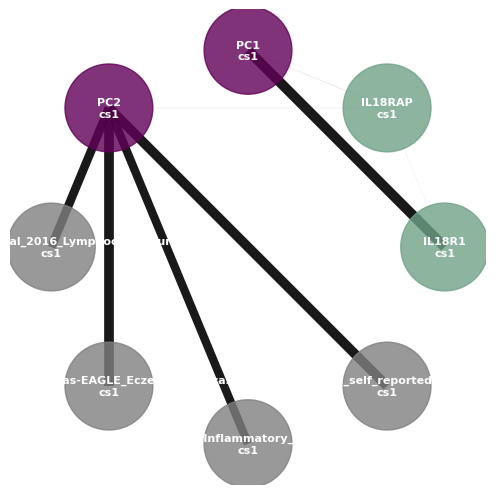

In [ ]:
# Create an undirected graph
G = nx.Graph()

# Add edges to the graph with weights
for index, row in pd.concat([cluster_pairs_qtl, cluster_gwas_pairs]).iterrows():
    G.add_edge(row['id1_short'], row['id2_short'], weight=row['PP.H4.abf'])

# Get edge weights for thickness
edge_weights = [G[u][v]['weight']*8 for u, v in G.edges()]
edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['Neither'] if 'gwas' in node else qtl_palette['pcQTL only'] if 'PC' in node else qtl_palette['eQTL only'] for node in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 5)) 

# Use a rescaled circular layout to prevent nodes from running off the edge
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, alpha=.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=.9, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.axis('off')  # Turn off the axis

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s17_e.png", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [399]:
# afc information 
pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqtl_afc])
susie_annotated['gene_id'] = susie_annotated['cluster_id'].str.split('_')
susie_explode = susie_annotated.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()
credible_set_grouped_afc[credible_set_grouped_afc['cs_id']==example_cs_id]

,phenotype_id,cs_id,tissue_id,gene_id,pip_afc,pip,pip_afc_weighted,abs_pip_afc_weighted
2758,ENSG00000115604.10_ENSG00000115607.9_pc2,ENSG00000115604.10_ENSG00000115607.9_pc2_cs_1,Skin_Sun_Exposed_Lower_leg,ENSG00000115604.10,0.521163,1.055409,0.493802,0.493802
2759,ENSG00000115604.10_ENSG00000115607.9_pc2,ENSG00000115604.10_ENSG00000115607.9_pc2_cs_1,Skin_Sun_Exposed_Lower_leg,ENSG00000115607.9,0.169333,1.055409,0.160443,0.160443


['chr2_102354072_T_TA_b38']
['chr2_102424707_T_C_b38']
['chr2_102354072_T_TA_b38']
['chr2_102424707_T_C_b38']
['chr2_102354072_T_TA_b38']
['chr2_102424707_T_C_b38']
['chr2_102354072_T_TA_b38']
['chr2_102424707_T_C_b38']


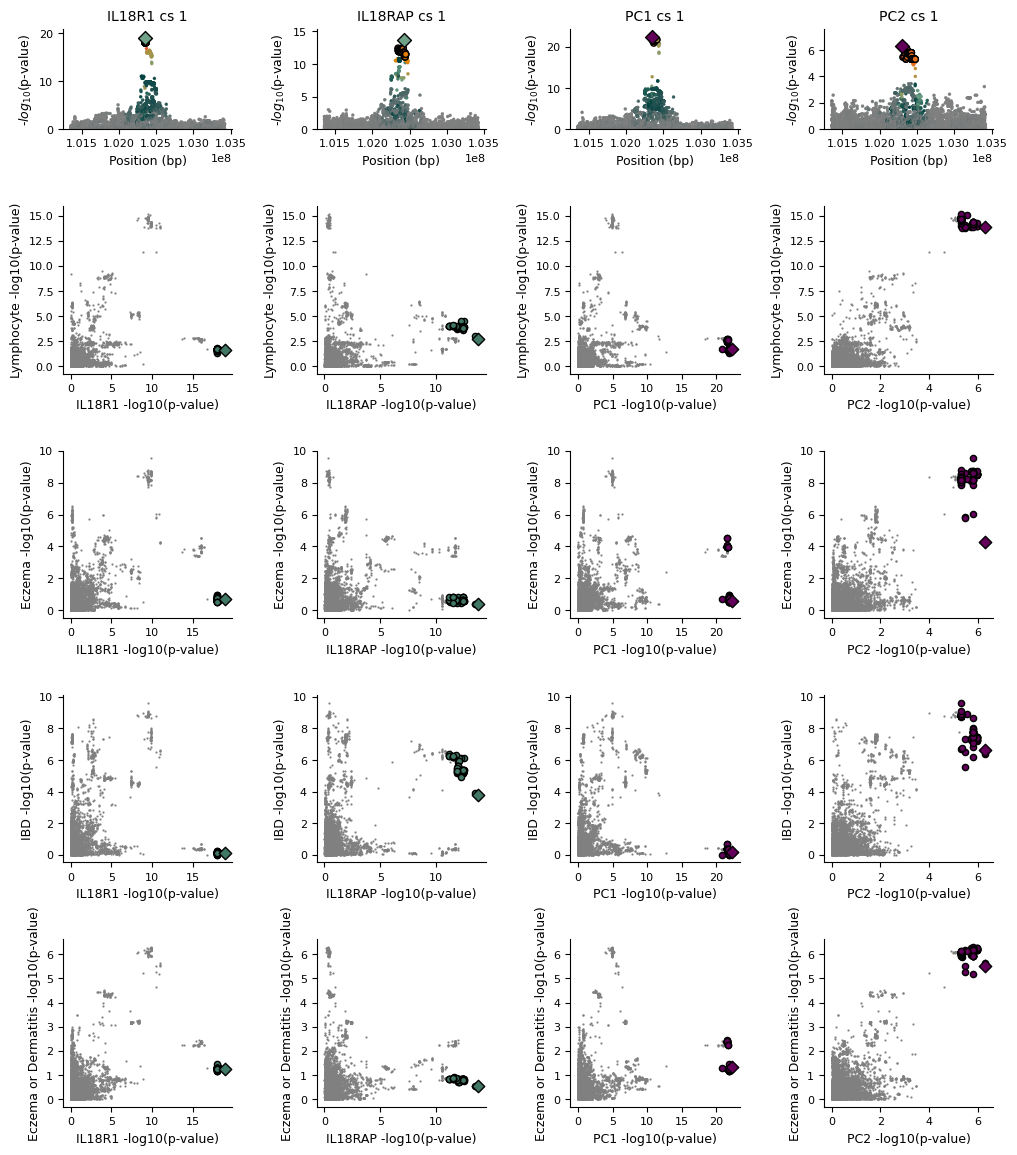

In [ ]:
# Create the combined figure with the new layout, making all plots span 1 column

example_cluster_cs = susie_annotated[susie_annotated['phenotype_id'].str.contains(example_cluster_id)]


gene_ids = example_cluster_id.split('_')
gene_names = [get_gene_name(g, config) for g in gene_ids]

# Calculate layout dimensions
num_cs = len(example_cluster_cs['cs_id'].unique())
num_gwas = len(example_gwas_traits)
egene_ids = [g for g in example_cluster_id.split('_')]
num_egenes = len(egene_ids)
num_pcs = 2  # Assuming two PC genes for this example

fig_cols = num_egenes + num_pcs 
fig_rows = len(example_gwas_traits) + 1
fig = plt.figure(figsize=(3 * fig_cols, 2.8*fig_rows))
gs = fig.add_gridspec(
    fig_rows, fig_cols,
    height_ratios=[1.5] + [2.5] * (fig_rows - 1),
    width_ratios=[1] * fig_cols,
    wspace=0.5,
    hspace=0.5
)

# Top row: Genome position plots (one per cs_id), each plot spans 1 column
genome_axes = []
col = 0
for i, cs_id in enumerate(example_cluster_cs['cs_id'].unique()):
    if col >= fig_cols:
        break
    ax = fig.add_subplot(gs[0, col])
    genome_axes.append(ax)
    if '_e_' in cs_id:
        cs_nominal = nominal_e[nominal_e['phenotype_id'] == cs_id.split('_cs')[0]].copy()
        lead_var_color = qtl_palette['eQTL only']
        pheno_label = get_gene_name(cs_id.split('_e_')[-1].split('_cs')[0], config) + '_cs' + cs_id.split('_cs')[-1]
    else:
        # For PC phenotypes, make sure the phenotype_id is correct
        pc_pheno_id = cs_id.split('_cs')[0]
        cs_nominal = nominal_pc[nominal_pc['phenotype_id'] == pc_pheno_id].copy()
        lead_var_color = qtl_palette['pcQTL only']
        # Try to extract the PC number robustly
        if '_pc' in cs_id:
            pc_num = cs_id.split('_pc')[-1].split('_')[0]
            pheno_label = f'PC{pc_num}_cs{cs_id.split("_cs")[-1]}'
        else:
            pheno_label = f'PC_cs{cs_id.split("_cs")[-1]}'

    cs_susie = susie_annotated[susie_annotated['cs_id'] == cs_id]
    cs_variant_ids = cs_susie['variant_id'].unique()
    lead_variant_id = cs_susie[cs_susie['pip'] == cs_susie['pip'].max()]['variant_id'].values[0]

    cs_nominal['in_cs'] = cs_nominal['variant_id'].isin(cs_variant_ids)
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    if lead_variant_id is not None and lead_variant_id in ld.index:
        ld_with_lead = ld.loc[lead_variant_id]
        cs_nominal = cs_nominal.set_index('variant_id')
        cs_nominal['ld_with_lead'] = ld_with_lead[cs_nominal.index].values ** 2
        cs_nominal = cs_nominal.reset_index()

    sns.scatterplot(
        data=cs_nominal, 
        x='pos', 
        y=-np.log10(cs_nominal['pval_nominal']), 
        hue='ld_with_lead', 
        palette=ld_palette, 
        edgecolor=None, 
        legend=False,
        s=5,
        alpha=1, 
        ax=ax, 
        hue_norm=ld_norm
    )
    if len(cs_susie) > 1:
        sns.scatterplot(
            data=cs_nominal[cs_nominal['in_cs']],
            x='pos',
            y=-np.log10(cs_nominal[cs_nominal['in_cs']]['pval_nominal']),
            hue='ld_with_lead', 
            palette=ld_palette, 
            marker='o',
            s=20,
            edgecolor='k',
            linewidth=1,
            alpha=1,
            ax=ax,
            legend=False, 
            hue_norm=ld_norm
        )  
    sns.scatterplot(
        data=cs_nominal[cs_nominal['variant_id'] == lead_variant_id],
        x='pos',
        y=-np.log10(cs_nominal[cs_nominal['variant_id'] == lead_variant_id]['pval_nominal']),
        marker='D',
        color=lead_var_color,
        s=50,
        edgecolor='k',
        linewidth=1,
        alpha=1,
        ax=ax,
        legend=False
    )   
    ax.set_ylabel('-' + r'$log_{10}$(p-value)')
    ax.set_xlabel('Position (bp)')
    ax.set_title(pheno_label.replace('_', ' '))
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylim(0, ax.get_ylim()[1] + 1)
    col += 1

# Middle rows: GWAS x QTL colocalization plots
# Each row is a GWAS trait, each row has (num_egenes + num_pcs) plots, each plot spans 1 column
gwas_qtl_axes = []
for gwas_trait_idx, gwas_trait in enumerate(example_gwas_traits):
    row_idx = 1 + gwas_trait_idx  # 1 for first GWAS, 2 for second GWAS, etc.
    col = 0
    # eGenes
    for egene_idx, egene_id in enumerate(egene_ids):
        if col >= fig_cols:
            break
        ax = fig.add_subplot(gs[row_idx, col])
        gwas_qtl_axes.append(ax)
        plot_egene_coloc(
            ax, get_gene_name(egene_id, config), egene_id, nominal_e, gwas_data[gwas_trait_idx], gwas_names[gwas_trait_idx], plot_example_cs=False
        )
        col += 1
    # PC genes
    for pc_idx in range(num_pcs):
        if col >= fig_cols:
            break
        ax = fig.add_subplot(gs[row_idx, col])
        gwas_qtl_axes.append(ax)
        plot_pcgene_coloc(
            ax, pc_idx+1, nominal_pc, gwas_data[gwas_trait_idx], gwas_names[gwas_trait_idx], plot_example_cs=False
        )
        col += 1

plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s17.pdf", 
           transparent=True, bbox_inches='tight', dpi=300)

plt.show()

In [406]:
print(f'Finemapped to a {example_cs["variant_id"].nunique()} variant credible set, with median ld {cs_nominal[cs_nominal["in_cs"]]["ld_with_lead"].median()}, LD range {cs_nominal[cs_nominal["in_cs"]]["ld_with_lead"].min()}-{cs_nominal[cs_nominal["in_cs"]]["ld_with_lead"].max()}')

Finemapped to a 87 variant credible set, with median ld 0.8911945289609999, LD range 0.8562115504889999-1.0


In [370]:
abc_df = pd.read_csv(f'{config["working_dir"]}/{config["abc_path"]}', sep='\t')
chr_abc_df = abc_df[(abc_df['chr'] == example_lead_variant_id.split('_')[0])]

In [ ]:
abc_rows = []
for idx, var_row in example_cs.iterrows():
    pos = int(var_row['variant_id'].split('_')[1])
    abc_rows.append(chr_abc_df[(chr_abc_df['start'] <= pos) & (chr_abc_df['end'] >= pos)])

abc_variant_df = pd.concat(abc_rows)
abc_variant_df[abc_variant_df['TargetGene'].isin(gene_names) & (abc_variant_df['CellType'].isin(['CD56-positive_natural_killer_cells-Roadmap', 'CD3-positive_T_cell-Roadmap', 'T-cell-ENCODE', 'natural_killer_cell-Corces2016']))].drop_duplicates('name')